In [1]:
from quantum_simulator_EC import system
import tensorflow as tf
import matplotlib.pyplot as plt
from reinforce_keras_EC import Agent
from copy import copy, deepcopy
import time
import os
import re
from IPython.display import clear_output
from termcolor import colored
import numpy as np

%matplotlib inline
%load_ext autoreload
%autoreload 2

## DIAGNOSTIC ROUTINES

In [2]:
def make_a_run(sys, agent_in, N_gates=100, PCA_nb=6):

    sys.initialise_all()
    qb =['']*sys.N_qubits
        
    for kk in range( N_gates ):
            
        state = sys.generate_net_input_state(PCA_nb)
        #net_input = sys.generate_net_input_FULL(PCA_nb)
        action = agent_in.choose_action( state )
        a_type = sys.get_action_type(action)
            
        reward1, reward2 = sys.apply_action(action)
            
        sys.time_evolve()
        sys.last_action = action
            
        a_type = sys.get_action_type(action)
        if a_type=='IDLE':
            for j in range(sys.N_qubits):
                qb[j]+='- '
        if a_type=='CNOT':
            qb1 = sys.cnot_pairs[sys.actions[action]][0]
            qb2 = sys.cnot_pairs[sys.actions[action]][1]
            qb[qb1]+=colored('C ', 'blue')
            qb[qb2]+=colored('X ', 'blue')
            for j in range(sys.N_qubits):
                if (j != qb1) and (j != qb2):
                    qb[j]+='- '
        if a_type=='BITFLIP':
            qb[ sys.actions[action] ]+='F '
            for j in range(sys.N_qubits):
                if (j != sys.actions[action]):
                    qb[j]+='- '
        if a_type=='ZMEASUREMENT':
            qb[sys.actions[action]]+=colored('M ', 'red')
            for j in range(sys.N_qubits):
                if (j != sys.actions[action]):
                    qb[j]+='- '
        
    print(" ")
    print("*******************************************************")
    for i in range(sys.N_qubits):
        print("Q"+str(i)+": ", qb[i])
    print("*******************************************************")
    print(" ")

def plot_RQ(sys, agent_in, num_trajectories=10, N_gates=200, PCA_nb=6, show_mean=True):
    """
    Generate num_trajectories rollouts of length N_gates using agent_in on sys,
    record RQ after each step, and plot all trajectories + their mean.

    Returns
    -------
    RQ_trajs : np.ndarray of shape (num_trajectories, N_gates)
        RQ values for each trajectory and gate step.
    """
    RQ_trajs = np.zeros((num_trajectories, N_gates), dtype=float)

    for tr in range(num_trajectories):
        sys.initialise_all()
        for kk in range(N_gates):
            state = sys.generate_net_input_state(PCA_nb)
            action = agent_in.choose_action(state)
            _r1, _r2 = sys.apply_action(action)

            sys.time_evolve()
            sys.last_action = action

            RQ_trajs[tr, kk] = sys.RQ()

    RQ_mean = RQ_trajs.mean(axis=0)

    plt.figure(figsize=(7, 4))
    for tr in range(num_trajectories):
        plt.plot(RQ_trajs[tr], alpha=0.4, linewidth=1)

    if show_mean:
        plt.plot(RQ_mean, linewidth=2.5, label="Mean")
        plt.legend()

    plt.xlabel("Gate step")
    plt.ylabel("RQ")
    plt.title(f"RQ trajectories: {num_trajectories} runs ({N_gates} gates each)")
    plt.show()

## MODEL INITIALISATION

In [3]:
qubit_nb=4
P=0.1
t_max=1200

s = system(t_max, N=qubit_nb, P=P)

agent = Agent(alpha=0.00005,  gamma=0.95, n_actions=len( s.actions ), lambda_entr=0)
RQ_history = []


/Users/admin/MACHINE_LEARNING/RL_FOR_QEC/quantum_simulator_EC.py:113: ComplexWarning: Casting complex values to real discards the imaginary part
  st_small.append(int( z ))


 
*******************************************************
Q0:  - - - - F - - X - - - X - - X - C F F - C - - - - - - X - - X - - - F - - C X - - - X - - - - C - X - C - - X - - M - - - - X X - - - X X - - C X - C - - X M M X C - - - - - F - - - - - - - X X X F - 
Q1:  - M C F - - - - - - F - - - - - - - - M - X - - - - - - F X C C F - - M - - - - - - C - - - - - - - X - - X C - M - M - F - - - - X C - - C X - - - - - - - - - - - F - C X X - - - - - - - - C - - - - 
Q2:  F - X - - - M - - - - C - - C C - - - - - - M - - - - - - C - X - C - - X X - M - - - X F F F X M C C X M - - F - - - - - X C - C - - C - X C X - - X F - - - - C X - - - - C - - - - - F - - - - - - M 
Q3:  - - - - - F - C M F - - M F - X X - - - X C - F F F - C - - - - - X - - C - C - F M - C - - - - - - - - - C - - - - - F - C - C X C X - C - - - C M - - F C - - - - - - X C - - - - F F - - - - C C - - 
*******************************************************
 


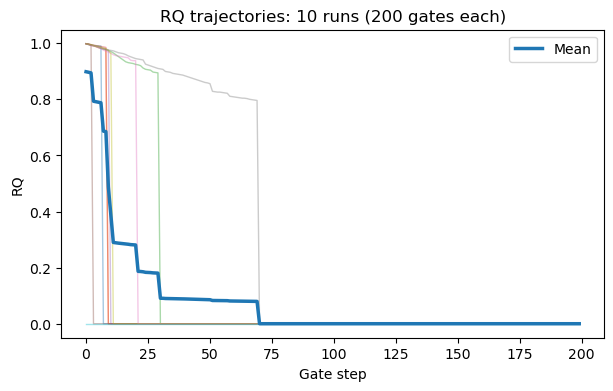

In [4]:
make_a_run(s, agent)
plot_RQ(s, agent)

## MODEL TRAINING 

In [5]:
batch_size = 64

envs = [system(T_dec=s.T_dec, T_single=s.T_single, N=s.N_qubits,
              Delta_t=s.Delta_t, P=s.P)
        for _ in range(batch_size)]

In [ ]:
num_epochs = 10000
N_gates = 200
PCA_nb = 6

# Create B environments once
envs = [system(T_dec=s.T_dec, T_single=s.T_single, N=s.N_qubits,
              Delta_t=s.Delta_t, P=s.P)
        for _ in range(batch_size)]

# Determine obs_dim once
obs_dim = len(envs[0].generate_net_input_state(PCA_nb))

RQ_history = []

t2 = -1
t1 = 0

for jj in range(num_epochs):

    clear_output(wait=False)
    print("-- number_of_epochs_trained: ", agent.number_of_epochs_trained)
    print('-- sequence generation time =', (t2 - t1) / batch_size)
    print('-- epoch: ', jj, end=': ')
    RQs_at_end = []

    t1 = time.time()

    # Reset all envs for this epoch
    for e in envs:
        e.initialise_all()

    # Preallocate trajectory buffers (fast + avoids ragged/object arrays)
    states  = np.zeros((batch_size, N_gates, obs_dim), dtype=np.float32)
    actions = np.zeros((batch_size, N_gates), dtype=np.int32)
    r1s     = np.zeros((batch_size, N_gates), dtype=np.float32)
    r2s     = np.zeros((batch_size, N_gates), dtype=np.float32)

    counter = 0

    for kk in range(N_gates):

        # progress dots (roughly same cadence as before)
        counter += 1
        if counter >= 8:
            print('.', end='')
            counter = 0

        # 1) build a batch of states
        states_batch = np.stack([e.generate_net_input_state(PCA_nb) for e in envs]).astype(np.float32, copy=False)   
        states[:, kk, :] = states_batch

        # 2) ONE policy call -> batch of actions
        a_batch = agent.choose_actions(states_batch)  # shape (B,)
        actions[:, kk] = a_batch

        # 3) step each env with its action
        for i, e in enumerate(envs):
            a = int(a_batch[i])
            reward1, reward2 = e.apply_action(a)
            r1s[i, kk] = reward1
            r2s[i, kk] = reward2

            e.time_evolve()
            e.last_action = a

    # End-of-trajectory stats
    for e in envs:
        RQs_at_end.append(e.RQ())

    # Store full batch (this is what store_batch is for) :contentReference[oaicite:2]{index=2}
    agent.store_batch(states, actions, r1s, r2s)

    t2 = time.time()
    RQ_history.append(np.mean(RQs_at_end))

    print("|", end='')
    agent.learn()  # note: learn currently loops over batch and calls policy per trajectory :contentReference[oaicite:3]{index=3}
    print("|")

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

base = (
    f"PGN"
    f"_Nq{s.N_qubits}"
    f"_P{float(s.P):.3g}"
    f"_Ng{N_gates}"
    f"_PCA{PCA_nb}"
    f"_bs{batch_size}"
    f"_ep{num_epochs}"
    f"_entr{agent.lambda_entr:.2g}"
)

# Save weights
weights_path = os.path.join(save_dir, base + ".weights.h5")
agent.policy.save_weights(weights_path)

# Save RQ history as ".d"
rq_path = os.path.join(save_dir, base + "_RQ_history.d")
np.savetxt(rq_path, np.array(RQ_history), fmt="%.10g")

print("Saved weights to:", weights_path)
print("Saved RQ history to:", rq_path)

-- number_of_epochs_trained:  1299
-- sequence generation time = 0.08693601191043854
-- epoch:  1299: 

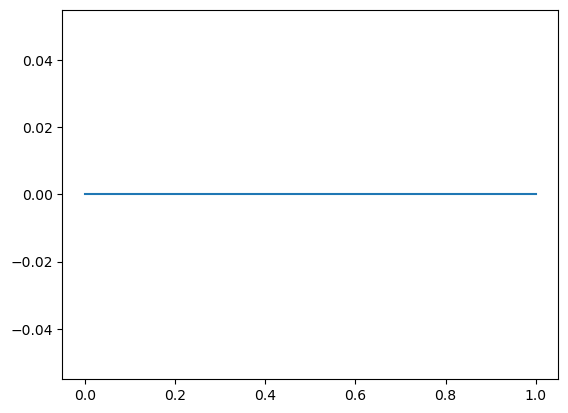

In [16]:
plt.plot(RQ_history)
plt.show()

## LOAD AGENT

In [24]:
# --- 1) Recreate the environment exactly as in training ---
s = system(1200, N=4, P=0.1)   # <-- use your training params

# --- 2) Recreate the agent exactly as in training ---
agent = Agent(
    alpha=0.00005,
    gamma=0.95,
    n_actions=len(s.actions),
    lambda_entr=0
)

# --- 3) Build the model variables (required before load_weights in subclassed models) ---
# Create a dummy input with the correct state dimension (PCA_nb here is 6 in your notebook)
PCA_nb = 6
dummy_state = s.generate_net_input_state(PCA_nb)              # shape (state_dim,)
dummy_state_tf = tf.constant(dummy_state[None, :], tf.float32) # shape (1, state_dim)
_ = agent.policy(dummy_state_tf, training=False)              # builds weights

# --- 4) Load weights ---
weights_path = "saved_models/PGN_Nq4_P0.1_Ng200_PCA6_bs64_ep100_entr0.weights.h5"
agent.policy.load_weights(weights_path)

print("Loaded weights from:", weights_path)

# --- 5) (Optional) Load RQ history saved alongside ---
rq_path = weights_path.replace(".weights.h5", "_RQ_history.d")
if os.path.exists(rq_path):
    RQ_history = np.loadtxt(rq_path)
    print("Loaded RQ_history from:", rq_path, "len=", len(RQ_history))

Loaded weights from: saved_models/PGN_Nq4_P0.1_Ng200_PCA6_bs64_ep100_entr0.weights.h5
Loaded RQ_history from: saved_models/PGN_Nq4_P0.1_Ng200_PCA6_bs64_ep100_entr0_RQ_history.d len= 100


 
*******************************************************
Q0:  - - - - F C - - X - - C C M - C M F C - C - C C - - M M - F M M F M M M M - - X - M - M C M C X M M - M - - C - C X X X - - M C - - M C C - - C C - F C - M F C - M M F - - C - M - - - X - M - C F - - 
Q1:  X - - X - - C - - F - - X - F - - - X X X - X - C F - - X - - - - - - - - - F - X - - - - - - - - - X - - - - C - - - C M F - - - X - X - X - X - - - - F - - X X - - - C M X X - - X - C - - M - - - F 
Q2:  - C - - - X X - - - C X - - - - - - - - - C - X - - - - - - - - - - - - - F - C - - - - - - X - - - C - X F X X - C C - - - - X F - - - - - X - X M - - - - - - C - - - X - - - - F C - - - - - - - - - 
Q3:  C X F C - - - - C - X - - - - X - - - C - X - - X - - - C - - - - - - - - - - - C - F - X - - C - - - - C - - - X - - - - - - - - C - - X C C - - - - X - - - - - - - - - - - C - - - - - F - - X - - - 
*******************************************************
 


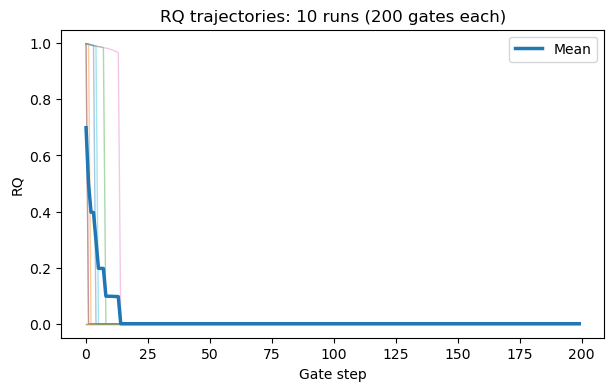

In [27]:
make_a_run(s, agent)
plot_RQ(s, agent)

In [7]:
(0.1*64*10000)/3600

17.77777777777778

In [ ]:
num_epochs = 2
N_gates = 200
PCA_nb = 6
batch_size = 10

agent.state_memory = []
agent.action_memory = []
agent.reward1_memory = []
agent.reward2_memory = []

t2=-1
t1=0

for jj in range(num_epochs):
    
    clear_output(wait=False)
    print("-- number_of_epochs_trained: ", agent.number_of_epochs_trained )
    print('-- sequence generation time =', (t2-t1)/batch_size  )
    print('-- epoch: ',jj, end=': ')
    RQs_at_end = []
    
    t1 = time.time()
        

    counter=0
    for ii in range(batch_size):
        
        counter+=1
        if counter >= 8:
            print('.',end='')
            counter=0
            
        seq_obsvs = []
        seq_acts = []
        seq_rwds1 = []
        seq_rwds2 = []
    
        s.initialise_all()
        
        for kk in range( N_gates ):
        
            state = s.generate_net_input_state(PCA_nb)
            #net_input = s.generate_net_input_FULL(PCA_nb)
            action = agent.choose_action( state )
            
            reward1, reward2 = s.apply_action(action)
            #new_state = s.generate_net_input_state(PCA_nb)
            
            seq_obsvs.append( state )
            seq_acts.append( action )
            seq_rwds1.append( reward1 )
            seq_rwds2.append( reward2 )
            
            s.time_evolve()
            s.last_action = action
            
        
        agent.store_transition(seq_obsvs, seq_acts, seq_rwds1, seq_rwds2)
        RQs_at_end.append( s.RQ() )
        
    t2 = time.time()
    
    RQ_history.append( np.array(RQs_at_end).mean() )
    
    print("|", end='')
    agent.learn()
    print("|")

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

base = (
    f"PGN"
    f"_Nq{s.N_qubits}"
    f"_P{float(s.P):.3g}"
    f"_Ng{N_gates}"
    f"_PCA{PCA_nb}"
    f"_bs{batch_size}"
    f"_ep{num_epochs}"
    f"_entr{agent.lambda_entr:.2g}"
)

# Save weights
weights_path = os.path.join(save_dir, base + ".weights.h5")
agent.policy.save_weights(weights_path)

# Save RQ history as ".d"
rq_path = os.path.join(save_dir, base + "_RQ_history.d")
np.savetxt(rq_path, np.array(RQ_history), fmt="%.10g")

print("Saved weights to:", weights_path)
print("Saved RQ history to:", rq_path)